# IPL First-Innings Score Prediction

A machine learning regression project that predicts the final score of an IPL first innings from the current match situation (batting team, bowling team, runs, wickets, balls bowled, and runs/wickets in the last 5 overs).

**Workflow:** match-level train/test split → group-aware cross-validation on the training matches to select the model → fit the selected model on all training matches → one final evaluation on the held-out test matches.

## 1. Import Libraries

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import dump, load

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

## 2. Load Dataset

Paths are built from the repository root, so the notebook works whether Jupyter is started from the repository root or from the `notebooks` folder.

The dataset is not included in the repository. Place it at `data/ipl_dataset.csv` before running (see `data/README.md`).

In [2]:
def find_project_root():
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / 'data' / 'ipl_dataset.csv').is_file():
            return folder
    raise FileNotFoundError('data/ipl_dataset.csv not found. The dataset is not included in the repository; place it there (see data/README.md).')


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / 'data' / 'ipl_dataset.csv'
MODEL_DIR = PROJECT_ROOT / 'models'

data = pd.read_csv(DATA_PATH)

expected_columns = ['mid', 'date', 'venue', 'batting_team', 'bowling_team', 'batsman', 'bowler',
                    'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5',
                    'striker', 'non-striker', 'total']
assert list(data.columns) == expected_columns, 'Unexpected dataset columns'
# The target (final innings total) must be a single value per match
assert (data.groupby('mid')['total'].nunique() == 1).all()

dates = pd.to_datetime(data['date'])
n_rows_raw, n_cols_raw = data.shape
n_matches_raw = data['mid'].nunique()
date_min, date_max = str(dates.min().date()), str(dates.max().date())
n_missing = int(data.isna().sum().sum())
n_duplicates = int(data.duplicated().sum())

print(f'Dataset shape:        {data.shape}')
print(f'Matches (unique mid): {n_matches_raw}')
print(f'Date range:           {date_min} to {date_max}')
print(f'Missing values:       {n_missing}')
print(f'Duplicate rows:       {n_duplicates}')

Dataset shape:        (76014, 15)
Matches (unique mid): 617
Date range:           2008-04-18 to 2017-05-21
Missing values:       0
Duplicate rows:       0


## 3. Exploratory Data Analysis

In [3]:
# First 5 rows
data.head()

,mid,date,venue,batting_team,bowling_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


In [4]:
# Summary statistics of numerical columns
data.describe()

,mid,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
count,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000
mean,308.627740,74.889349,2.415844,9.783068,33.216434,1.120307,24.962283,8.869287,160.901452
std,178.156878,48.823327,2.015207,5.772587,14.914174,1.053343,20.079752,10.795742,29.246231
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000
25%,154.000000,34.000000,1.000000,4.600000,24.000000,0.000000,10.000000,1.000000,142.000000
50%,308.000000,70.000000,2.000000,9.600000,34.000000,1.000000,20.000000,5.000000,162.000000
75%,463.000000,111.000000,4.000000,14.600000,43.000000,2.000000,35.000000,13.000000,181.000000
max,617.000000,263.000000,10.000000,19.600000,113.000000,7.000000,175.000000,109.000000,263.000000


In [5]:
# Non-null counts and data types of each column
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  str    
 2   venue           76014 non-null  str    
 3   batting_team    76014 non-null  str    
 4   bowling_team    76014 non-null  str    
 5   batsman         76014 non-null  str    
 6   bowler          76014 non-null  str    
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), str(6)
memory usage: 8.7 MB


In [6]:
# Number of unique values in each column
data.nunique()

mid               617
date              442
venue              35
batting_team       14
bowling_team       14
batsman           411
bowler            329
runs              252
wickets            11
overs             140
runs_last_5       102
wickets_last_5      8
striker           155
non-striker        88
total             138
dtype: int64

The target `total` is the final first-innings score, repeated on every ball of an innings. The distribution below uses one value per match.

count    617.0
mean     160.3
std       29.7
min       67.0
25%      141.0
50%      161.0
75%      181.0
max      263.0
Name: total, dtype: float64


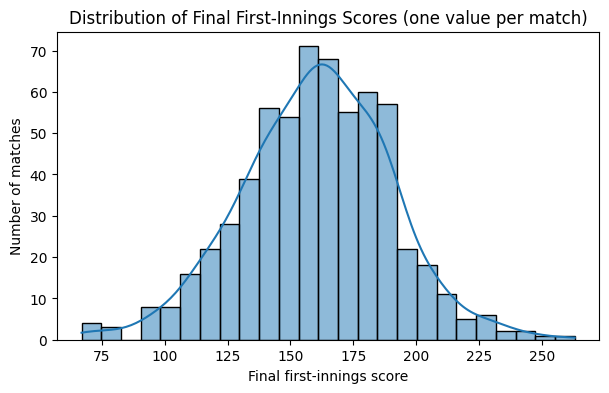

In [7]:
match_totals = data.groupby('mid')['total'].first()
print(match_totals.describe().round(1))

plt.figure(figsize=(7, 4))
sns.histplot(match_totals, bins=25, kde=True)
plt.xlabel('Final first-innings score')
plt.ylabel('Number of matches')
plt.title('Distribution of Final First-Innings Scores (one value per match)')
plt.show()

## 4. Data Preprocessing

### 4.1 Remove Irrelevant Features

The columns `date`, `venue`, `batsman`, `bowler`, `striker` and `non-striker` are not used as model inputs and are dropped.

The match identifier `mid` is also not a model input, but it is **kept until the train-test split**: every row is one ball, so `mid` is needed to keep all rows of a match on the same side of the split and inside the same cross-validation fold.

In [8]:
irrelevant = ['date', 'venue', 'batsman', 'bowler', 'striker', 'non-striker']
print(f'Before removing irrelevant columns: {data.shape}')
data = data.drop(columns=irrelevant)
print(f'After removing irrelevant columns:  {data.shape}')

Before removing irrelevant columns: (76014, 15)
After removing irrelevant columns:  (76014, 9)


### 4.2 Filter Teams

Only eight teams from the historical dataset are retained to maintain a consistent team set for modeling. Rows where either the batting team or the bowling team is outside this list are removed.

In [9]:
const_teams = ['Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals',
               'Mumbai Indians', 'Kings XI Punjab', 'Royal Challengers Bangalore',
               'Delhi Daredevils', 'Sunrisers Hyderabad']

print(f'Before filtering teams: {data.shape}')
data = data[data['batting_team'].isin(const_teams) & data['bowling_team'].isin(const_teams)]
n_rows_after_teams = len(data)
print(f'After filtering teams:  {data.shape}')

Before filtering teams: (76014, 9)
After filtering teams:  (53811, 9)


### 4.3 Convert Cricket Overs and Filter Overs

`overs` is written in cricket notation, so it is **not an ordinary decimal number**. The data below shows how it works in this dataset: the digit after the point counts the legal balls bowled in the current over, and runs from 0 to 6. After `5.6` (the end of the 6th over) the next ball is `6.1`. A `.0` appears when an extra delivery (wide or no-ball) is bowled before the first legal ball of an over, and an extra repeats the previous value (for example `0.2` twice).

So the number of legal balls bowled is `6 × completed overs + digit`. This is stored as `balls_elapsed` (for example `5.1 → 31`, `5.6 → 36`, `6.0 → 36`) and replaces `overs` as a model feature.

In [10]:
tenths = (data['overs'] * 10).round().astype(int)
print('Rows by digit after the point in overs:')
print((tenths % 10).value_counts().sort_index().to_string())

first_match = data.loc[data['mid'] == data['mid'].iloc[0], 'overs']
print('\nOne match, overs between 4.4 and 6.2:', first_match[first_match.between(4.4, 6.2)].tolist())

Rows by digit after the point in overs:
overs
0     341
1    8975
2    8944
3    8960
4    8975
5    8975
6    8641

One match, overs between 4.4 and 6.2: [4.4, 4.5, 4.6, 5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 6.1, 6.2]


In [11]:
def overs_to_balls(overs):
    # Cricket overs (completed overs + legal balls in the current over) -> legal balls bowled
    tenths = np.round(np.asarray(overs, dtype=float) * 10).astype(int)
    completed_overs, balls_in_over = np.divmod(tenths, 10)
    if np.any((balls_in_over < 0) | (balls_in_over > 6)):
        raise ValueError('The digit after the point in overs must be between 0 and 6')
    return completed_overs * 6 + balls_in_over


data = data.copy()
data['balls_elapsed'] = overs_to_balls(data['overs'])
assert data['balls_elapsed'].between(0, 120).all()
data = data.drop(columns='overs')

print('Examples: 4.6 ->', overs_to_balls(4.6), '| 5.0 ->', overs_to_balls(5.0),
      '| 5.1 ->', overs_to_balls(5.1), '| 5.6 ->', overs_to_balls(5.6), '| 19.6 ->', overs_to_balls(19.6))

Examples: 4.6 -> 30 | 5.0 -> 30 | 5.1 -> 31 | 5.6 -> 36 | 19.6 -> 120


The first 5 overs of every innings are removed, so the model is trained only on situations after at least 5 completed overs (`balls_elapsed >= 30`). This uses the converted value, so the end of the 5th over is treated the same way whether it was recorded as `4.6` or `5.0`.

In [12]:
print(f'Before filtering overs: {data.shape}')
data = data[data['balls_elapsed'] >= 30]
n_rows_modeling = len(data)
n_matches_modeling = data['mid'].nunique()
print(f'After filtering overs:  {data.shape} ({n_matches_modeling} matches)')
data.head()

Before filtering overs: (53811, 9)
After filtering overs:  (40545, 9) (437 matches)


,mid,batting_team,bowling_team,runs,wickets,runs_last_5,wickets_last_5,total,balls_elapsed
31,1,Kolkata Knight Riders,Royal Challengers Bangalore,60,0,59,0,222,30
32,1,Kolkata Knight Riders,Royal Challengers Bangalore,61,0,59,0,222,31
33,1,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,59,1,222,32
34,1,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,59,1,222,33
35,1,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,59,1,222,34


### 4.4 Define Features and Preprocessing Pipeline

Batting and bowling teams are one-hot encoded and the numerical features are standardised. Both steps are part of the scikit-learn `Pipeline` of every model, so they are fitted only on the data a model is trained on (each training fold during cross-validation, or the full training set for the final model) and are applied unchanged to validation, test and new data.

In [13]:
categorical_features = ['batting_team', 'bowling_team']
numeric_features = ['runs', 'wickets', 'balls_elapsed', 'runs_last_5', 'wickets_last_5']
feature_columns = categorical_features + numeric_features
target_column = 'total'

# The target and the match identifier must never be model inputs
assert target_column not in feature_columns
assert 'mid' not in feature_columns
assert set(feature_columns).issubset(data.columns)

print('Categorical features:', categorical_features)
print('Numerical features:  ', numeric_features)
print('Target:              ', target_column)


def build_pipeline(regressor):
    preprocessor = ColumnTransformer([
        ('team_encoder', OneHotEncoder(sparse_output=False), categorical_features),
        ('scaler', StandardScaler(), numeric_features),
    ])
    return Pipeline([('preprocessor', preprocessor), ('regressor', regressor)])

Categorical features: ['batting_team', 'bowling_team']
Numerical features:   ['runs', 'wickets', 'balls_elapsed', 'runs_last_5', 'wickets_last_5']
Target:               total


## 5. Train-Test Split

The dataset has one row per ball, so many rows belong to the same match. The data is therefore split **by match** (`GroupShuffleSplit` on `mid`): 80% of the matches for training and 20% for testing. The test matches are not used again until the final evaluation in Section 7.

In [14]:
X = data[feature_columns]
y = data[target_column]
groups = data['mid']

splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

assert target_column not in X_train.columns and target_column not in X_test.columns

train_matches = set(groups_train)
test_matches = set(groups_test)
assert train_matches.isdisjoint(test_matches), 'A match appears in both train and test'

n_train_rows, n_test_rows = len(X_train), len(X_test)
n_train_matches, n_test_matches = len(train_matches), len(test_matches)
print(f'Training set: {n_train_rows} rows from {n_train_matches} matches')
print(f'Testing set:  {n_test_rows} rows from {n_test_matches} matches')
print(f'Matches in both sets: {len(train_matches & test_matches)}')

Training set: 32376 rows from 349 matches
Testing set:  8169 rows from 88 matches
Matches in both sets: 0


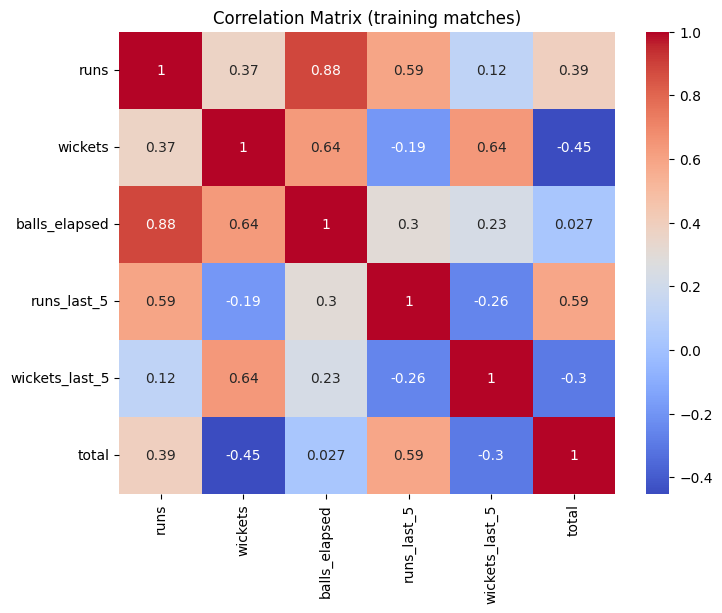

In [15]:
# Correlation between numerical features and the target (training matches only)
train_numeric = X_train[numeric_features].assign(total=y_train)
plt.figure(figsize=(8, 6))
sns.heatmap(train_numeric.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix (training matches)')
plt.show()

## 6. Model Selection with Group-Aware Cross-Validation

Models are compared using **5-fold `GroupKFold` cross-validation on the training matches only**. Every fold keeps all rows of a match together, so rows from one match are never in both the fitting part and the validation part of a fold. The test matches are not used in this section.

The selection criterion, fixed before looking at any results, is the **highest mean cross-validation R²**.

In [16]:
cv = GroupKFold(n_splits=5)
scoring = {'r2': 'r2', 'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error'}


def group_cv_scores(model):
    scores = cross_validate(model, X_train, y_train, groups=groups_train,
                            cv=cv, scoring=scoring, n_jobs=-1)
    return {
        'R² mean': scores['test_r2'].mean(), 'R² std': scores['test_r2'].std(),
        'MAE mean': -scores['test_mae'].mean(), 'MAE std': scores['test_mae'].std(),
        'RMSE mean': -scores['test_rmse'].mean(), 'RMSE std': scores['test_rmse'].std(),
    }


def make_candidates(lasso_alpha):
    return {
        'Decision Tree': build_pipeline(DecisionTreeRegressor(random_state=42)),
        'Linear Regression': build_pipeline(LinearRegression()),
        'Random Forest': build_pipeline(RandomForestRegressor(random_state=42)),
        'Lasso Regression': build_pipeline(Lasso(alpha=lasso_alpha, max_iter=10000)),
        'Support Vector Regression': build_pipeline(SVR()),
        'Neural Network': build_pipeline(MLPRegressor(activation='logistic', max_iter=10000, random_state=42)),
    }

### 6.1 Lasso Regularisation Strength

The regularisation strength `alpha` of Lasso Regression is chosen with the same group-aware cross-validation, using the training matches only (this replaces `LassoCV`, whose internal cross-validation does not keep matches together). The other models use their default hyperparameters.

In [17]:
alphas = np.logspace(-3, 1, 9)
alpha_rows = []
for alpha in alphas:
    row = group_cv_scores(build_pipeline(Lasso(alpha=alpha, max_iter=10000)))
    alpha_rows.append({'alpha': alpha, **row})

alpha_table = pd.DataFrame(alpha_rows).set_index('alpha').round(4)
best_alpha = float(alpha_table['R² mean'].idxmax())
print(f'Selected alpha (highest mean CV R²): {best_alpha:.4g}')
alpha_table[['R² mean', 'R² std', 'MAE mean', 'RMSE mean']]

Selected alpha (highest mean CV R²): 0.1


,R² mean,R² std,MAE mean,RMSE mean
alpha,,,,
0.001000,0.6358,0.0343,13.5417,17.9031
0.003162,0.6359,0.0342,13.5388,17.9011
0.010000,0.6362,0.0341,13.5298,17.8944
0.031623,0.6371,0.0337,13.5038,17.8737
0.100000,0.6392,0.0330,13.4452,17.8258
0.316228,0.6389,0.0350,13.4030,17.8298
1.000000,0.6144,0.0362,14.0967,18.4289
3.162278,0.5247,0.0293,16.1859,20.5002
10.000000,0.2668,0.0175,20.4007,25.5302


### 6.2 Cross-Validation Comparison of All Models

In [18]:
candidates = make_candidates(lasso_alpha=best_alpha)

cv_rows = {name: group_cv_scores(model) for name, model in candidates.items()}
cv_results = pd.DataFrame(cv_rows).T.round(4)
cv_results.index.name = 'Model'
cv_results.sort_values('R² mean', ascending=False)

,R² mean,R² std,MAE mean,MAE std,RMSE mean,RMSE std
Model,,,,,,
Lasso Regression,0.6392,0.0330,13.4452,0.6554,17.8258,0.9245
Linear Regression,0.6358,0.0343,13.5431,0.6071,17.9040,0.8578
Support Vector Regression,0.6259,0.0428,13.7310,0.8144,18.1368,1.0962
Random Forest,0.5178,0.0596,15.1091,0.6187,20.5643,0.8904
Neural Network,0.3713,0.0928,17.7871,0.6121,23.4396,0.7202
Decision Tree,0.2276,0.1017,19.3353,0.3656,25.9918,0.4790


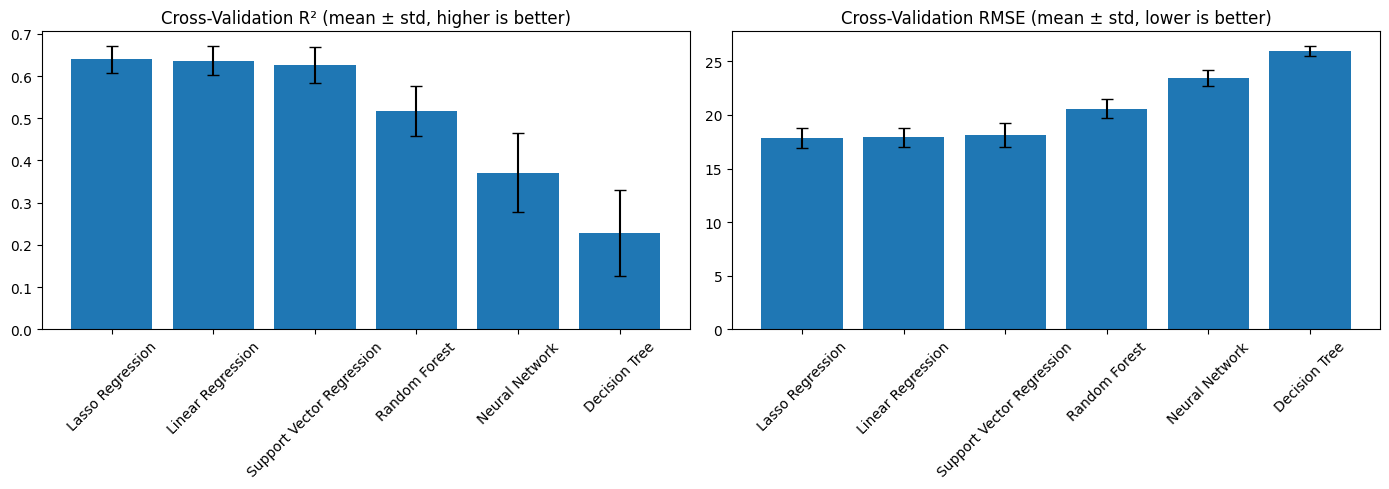

In [19]:
ordered = cv_results.sort_values('R² mean', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(ordered.index, ordered['R² mean'], yerr=ordered['R² std'], capsize=4)
axes[0].set_title('Cross-Validation R² (mean ± std, higher is better)')
axes[1].bar(ordered.index, ordered['RMSE mean'], yerr=ordered['RMSE std'], capsize=4)
axes[1].set_title('Cross-Validation RMSE (mean ± std, lower is better)')

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

### 6.3 Select the Final Model

In [20]:
final_model_name = cv_results['R² mean'].idxmax()
print(f'Selected model (highest mean cross-validation R²): {final_model_name}')
if final_model_name == 'Lasso Regression':
    print(f'Selected Lasso alpha: {best_alpha:.4g}')

Selected model (highest mean cross-validation R²): Lasso Regression
Selected Lasso alpha: 0.1


## 7. Final Training and Held-Out Test Evaluation

The selected model is fitted on **all training matches** and evaluated **once** on the held-out test matches. These metrics were not used to choose the model.

In [21]:
final_model = clone(candidates[final_model_name]).fit(X_train, y_train)

test_pred = final_model.predict(X_test)
test_mse = mean_squared_error(y_test, test_pred)
test_metrics = {
    'R²': r2_score(y_test, test_pred),
    'MAE': mean_absolute_error(y_test, test_pred),
    'MSE': test_mse,
    'RMSE': float(np.sqrt(test_mse)),
}

print(f'Final model: {final_model_name}')
print(f'Evaluated on {n_test_rows} rows from {n_test_matches} held-out test matches')
pd.DataFrame(test_metrics, index=['Test set']).round(4)

Final model: Lasso Regression
Evaluated on 8169 rows from 88 held-out test matches


,R²,MAE,MSE,RMSE
Test set,0.5962,13.4329,337.926,18.3828


## 8. Final Prediction

`predict_score` takes the match situation (with `overs` in cricket notation, for example `10.2`), converts it to `balls_elapsed` with the same function used for training, and passes it to the fitted pipeline.

### Illustrative Predictions

Six manually entered match situations with the final first-innings score recorded for each in the original project. These examples are illustrative and are not a substitute for the held-out test-set evaluation.

In [22]:
def predict_score(batting_team, bowling_team, runs, wickets, overs,
                  runs_last_5, wickets_last_5, model=None):
    model = final_model if model is None else model
    match_state = pd.DataFrame([{
        'batting_team': batting_team,
        'bowling_team': bowling_team,
        'runs': runs,
        'wickets': wickets,
        'balls_elapsed': int(overs_to_balls(overs)),
        'runs_last_5': runs_last_5,
        'wickets_last_5': wickets_last_5,
    }], columns=feature_columns)
    return int(round(model.predict(match_state)[0]))

In [23]:
examples = [
    # batting team, bowling team, runs, wickets, overs, runs_last_5, wickets_last_5, actual final score
    ('Delhi Daredevils',      'Chennai Super Kings', 68,  3, 10.2, 29, 1, 147),
    ('Mumbai Indians',        'Kings XI Punjab',     113, 2, 12.3, 55, 0, 176),
    ('Kings XI Punjab',       'Rajasthan Royals',    118, 1, 14.0, 45, 0, 185),
    ('Kolkata Knight Riders', 'Chennai Super Kings', 150, 4, 18.0, 57, 1, 172),
    ('Delhi Daredevils',      'Mumbai Indians',      96,  8, 18.0, 18, 4, 110),
    ('Kings XI Punjab',       'Chennai Super Kings', 129, 6, 18.0, 34, 2, 153),
]

rows = []
for bat, bowl, runs, wkts, overs, runs5, wkts5, actual in examples:
    predicted = predict_score(bat, bowl, runs, wkts, overs, runs5, wkts5)
    rows.append({
        'Batting Team': bat,
        'Bowling Team': bowl,
        'Overs': overs,
        'Score at that point': f'{runs}/{wkts}',
        'Predicted Score': predicted,
        'Actual Score': actual,
        'Absolute Error': abs(predicted - actual),
    })

pd.DataFrame(rows)

,Batting Team,Bowling Team,Overs,Score at that point,Predicted Score,Actual Score,Absolute Error
0,Delhi Daredevils,Chennai Super Kings,10.2,68/3,148,147,1
1,Mumbai Indians,Kings XI Punjab,12.3,113/2,190,176,14
2,Kings XI Punjab,Rajasthan Royals,14.0,118/1,187,185,2
3,Kolkata Knight Riders,Chennai Super Kings,18.0,150/4,171,172,1
4,Delhi Daredevils,Mumbai Indians,18.0,96/8,100,110,10
5,Kings XI Punjab,Chennai Super Kings,18.0,129/6,144,153,9


## 9. Save Final Model

The saved object is the complete fitted pipeline (team encoder + scaler + selected model), trained on the training matches. The `models` folder is created if it does not exist. The saved file is then reloaded and checked against the in-memory model.

In [24]:
MODEL_DIR.mkdir(exist_ok=True)
model_path = MODEL_DIR / (final_model_name.lower().replace(' ', '_') + '_model.joblib')
dump(final_model, model_path)

loaded_model = load(model_path)
assert 'preprocessor' in loaded_model.named_steps, 'Preprocessing is not part of the saved model'
assert np.allclose(loaded_model.predict(X_test), final_model.predict(X_test))

for bat, bowl, runs, wkts, overs, runs5, wkts5, actual in examples:
    assert (predict_score(bat, bowl, runs, wkts, overs, runs5, wkts5, model=loaded_model)
            == predict_score(bat, bowl, runs, wkts, overs, runs5, wkts5))

model_file = str(model_path.relative_to(PROJECT_ROOT).as_posix())
print(f'Final model saved to {model_file} and reloaded successfully')
print('Prediction from the reloaded model (Mumbai Indians vs Kings XI Punjab, 113/2 after 12.3 overs):',
      predict_score('Mumbai Indians', 'Kings XI Punjab', 113, 2, 12.3, 55, 0, model=loaded_model))

Final model saved to models/lasso_regression_model.joblib and reloaded successfully
Prediction from the reloaded model (Mumbai Indians vs Kings XI Punjab, 113/2 after 12.3 overs): 190
